# Tier 4 · Notebook 19 — Pretraining → Fine-Tuning

> **Goal:** understand the **transfer-learning** paradigm that makes modern AI practical — pretrain a model once on a large generic task (self-supervised), then **fine-tune** it cheaply on a small downstream task. We demonstrate the core payoff: a pretrained model learns a new task from *far fewer* labeled examples than one trained from scratch.

**Why this is the whole game.** Labeled data is expensive; unlabeled data (raw text/images) is nearly free. **Pretraining** learns general-purpose representations from mountains of unlabeled data via a self-supervised objective (predict the next token — GPT; predict masked tokens — BERT). Those representations then **transfer**: fine-tuning on a small labeled dataset adapts them to a specific task with little data and little compute. This is why you don't train GPT-4 from scratch for your chatbot — you start from a pretrained model. This notebook shows *why transfer works* in a controlled setting where we can prove it.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 0. A controlled setup: two "languages"

To *prove* transfer helps (not just assert it), we use a controlled synthetic task. We define two "languages" — sequences generated by two different **Markov chains** over a small alphabet (each language has its own characteristic transition statistics, like different writing styles). Then:
- **Pretraining task** (self-supervised, unlimited data): language-model the *mixed, unlabeled* stream — learn each language's statistics by predicting the next token.
- **Downstream task** (supervised, *scarce* labels): given a sequence, classify **which language** produced it.

The bet: the pretrained model already learned the sequence statistics, so it can classify from very few labels — while a from-scratch classifier needs many.


In [2]:
V, L = 12, 24     # vocab size, sequence length
def make_chain(seed):
    rng = np.random.default_rng(seed)
    T = rng.dirichlet(np.ones(V)*0.3, size=V)   # a random transition matrix (peaky)
    return T
chains = [make_chain(1), make_chain(2)]

def sample_seq(chain, rng):
    s = [rng.integers(V)]
    for _ in range(L-1):
        s.append(rng.choice(V, p=chain[s[-1]]))
    return s

rng = np.random.default_rng(0)
# pretraining corpus: lots of UNLABELED sequences from both languages, mixed
pretrain_seqs = np.array([sample_seq(chains[rng.integers(2)], rng) for _ in range(8000)])
# downstream: LABELED sequences (label = which chain). We'll vary how many labels we allow.
def labeled_set(n, seed):
    r = np.random.default_rng(seed); X, y = [], []
    for _ in range(n):
        c = r.integers(2); X.append(sample_seq(chains[c], r)); y.append(c)
    return torch.tensor(X), torch.tensor(y)
Xtest, ytest = labeled_set(2000, 999)
print(f"vocab {V}, seq len {L}; pretrain corpus {pretrain_seqs.shape}, test set {Xtest.shape}")


vocab 12, seq len 24; pretrain corpus (8000, 24), test set torch.Size([2000, 24])


## 1. The model: a small transformer with two heads

One shared transformer **backbone** (embeddings + a couple of transformer blocks), with two task-specific heads:
- an **LM head** (predict next token) used for **pretraining**,
- a **classification head** (predict the language label) used for **fine-tuning**.

The backbone is what *transfers* — pretraining shapes it, fine-tuning reuses it.


In [3]:
class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.ln1=nn.LayerNorm(d); self.ln2=nn.LayerNorm(d)
        self.h,self.dk=h,d//h; self.qkv=nn.Linear(d,3*d); self.proj=nn.Linear(d,d)
        self.mlp=nn.Sequential(nn.Linear(d,4*d),nn.GELU(),nn.Linear(4*d,d))
        self.register_buffer("m", torch.tril(torch.ones(L,L)).bool())
    def forward(self,x):
        B,T,C=x.shape; q,k,v=self.qkv(self.ln1(x)).split(C,2)
        sp=lambda t:t.view(B,T,self.h,self.dk).transpose(1,2); q,k,v=sp(q),sp(k),sp(v)
        a=(q@k.transpose(-2,-1))/self.dk**0.5; a=a.masked_fill(~self.m[:T,:T],float("-inf"))
        x=x+self.proj((F.softmax(a,-1)@v).transpose(1,2).reshape(B,T,C))
        return x+self.mlp(self.ln2(x))

class Backbone(nn.Module):
    def __init__(self, d=64, h=4, n_layers=2):
        super().__init__(); self.tok=nn.Embedding(V,d); self.pos=nn.Embedding(L,d)
        self.blocks=nn.ModuleList([Block(d,h) for _ in range(n_layers)]); self.ln=nn.LayerNorm(d); self.d=d
    def forward(self,x):
        h=self.tok(x)+self.pos(torch.arange(x.size(1),device=x.device))
        for b in self.blocks: h=b(h)
        return self.ln(h)          # (B,T,d) contextual features

class LMHead(nn.Module):
    def __init__(self,d): super().__init__(); self.head=nn.Linear(d,V)
    def forward(self,h): return self.head(h)
class ClsHead(nn.Module):
    def __init__(self,d): super().__init__(); self.head=nn.Linear(d,2)
    def forward(self,h): return self.head(h.mean(1))   # pool over sequence -> class logits

print("backbone + heads defined")


backbone + heads defined


## 2. Pretrain the backbone (self-supervised language modeling)

Train the backbone + LM head on the **unlabeled** mixed corpus to predict the next token. No labels used — this is the "free data" phase. The backbone learns each language's transition statistics.


In [4]:
pt_data = torch.tensor(pretrain_seqs, device=device)
backbone = Backbone().to(device); lm_head = LMHead(backbone.d).to(device)
opt = torch.optim.AdamW(list(backbone.parameters())+list(lm_head.parameters()), lr=3e-3)
for step in range(1500):
    ix = torch.randint(0, len(pt_data), (128,), device=device)
    b = pt_data[ix]; h = backbone(b[:, :-1]); logits = lm_head(h)
    loss = F.cross_entropy(logits.reshape(-1, V), b[:, 1:].reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 500 == 0 or step == 1499: print(f"pretrain step {step:4d}  LM loss {loss.item():.3f}")
pretrained_state = {k: v.clone() for k, v in backbone.state_dict().items()}    # save for reuse
print("✅ backbone pretrained (self-supervised, no labels)")


pretrain step    0  LM loss 2.578


pretrain step  500  LM loss 1.517


pretrain step 1000  LM loss 1.459


pretrain step 1499  LM loss 1.432
✅ backbone pretrained (self-supervised, no labels)


## 3. The transfer experiment: pretrained vs from-scratch, across label budgets

Now the head-to-head. For a range of **labeled-set sizes**, we train the classifier two ways:
- **from scratch**: a fresh random backbone + classification head, trained only on the labeled set.
- **fine-tuned**: the *pretrained* backbone + a fresh classification head, fine-tuned on the same labeled set.

If pretraining helps, the fine-tuned model should win — especially when labels are scarce.


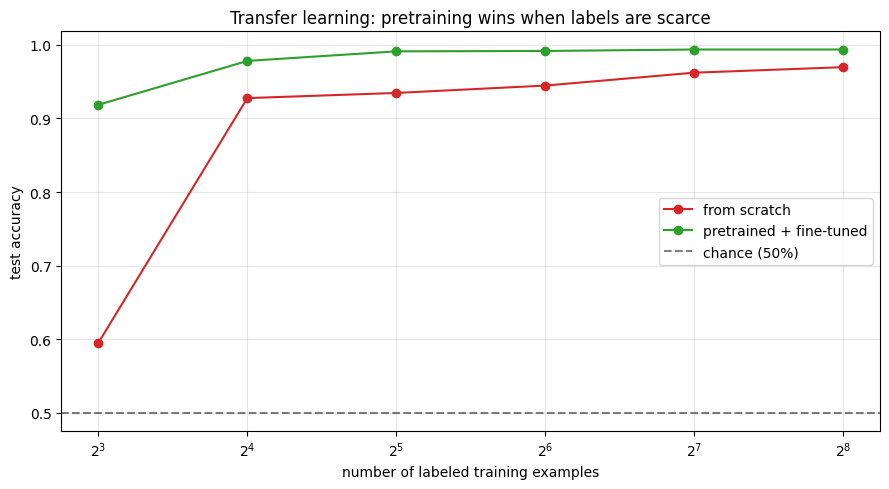

     8 labels: from-scratch 0.596  |  fine-tuned 0.919
    16 labels: from-scratch 0.928  |  fine-tuned 0.978
    32 labels: from-scratch 0.935  |  fine-tuned 0.991
    64 labels: from-scratch 0.945  |  fine-tuned 0.992
   128 labels: from-scratch 0.962  |  fine-tuned 0.994
   256 labels: from-scratch 0.970  |  fine-tuned 0.994


In [5]:
def train_classifier(n_labels, pretrained, epochs=60, seed=0):
    torch.manual_seed(seed)
    Xtr, ytr = labeled_set(n_labels, seed+100); Xtr, ytr = Xtr.to(device), ytr.to(device)
    bb = Backbone().to(device)
    if pretrained: bb.load_state_dict(pretrained_state)     # start from pretrained weights
    head = ClsHead(bb.d).to(device)
    opt = torch.optim.AdamW(list(bb.parameters())+list(head.parameters()), lr=1e-3)
    for _ in range(epochs):
        logits = head(bb(Xtr)); loss = F.cross_entropy(logits, ytr)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (head(bb(Xtest.to(device))).argmax(1) == ytest.to(device)).float().mean().item()
    return acc

label_budgets = [8, 16, 32, 64, 128, 256]
scratch_acc = [train_classifier(n, pretrained=False) for n in label_budgets]
finetune_acc = [train_classifier(n, pretrained=True)  for n in label_budgets]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(label_budgets, scratch_acc, "-o", color="tab:red", label="from scratch")
ax.plot(label_budgets, finetune_acc, "-o", color="tab:green", label="pretrained + fine-tuned")
ax.axhline(0.5, ls="--", color="k", alpha=0.5, label="chance (50%)")
ax.set_xscale("log", base=2)
ax.set_title("Transfer learning: pretraining wins when labels are scarce")
ax.set_xlabel("number of labeled training examples"); ax.set_ylabel("test accuracy")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
for n, s, f in zip(label_budgets, scratch_acc, finetune_acc):
    print(f"  {n:>4d} labels: from-scratch {s:.3f}  |  fine-tuned {f:.3f}")
assert finetune_acc[0] > scratch_acc[0] + 0.1, (
    f"pretraining bought nothing in the low-label regime: {label_budgets[0]} labels gave "
    f"from-scratch {scratch_acc[0]:.3f} vs fine-tuned {finetune_acc[0]:.3f}")
assert all(f >= s for f, s in zip(finetune_acc, scratch_acc)), \
    "fine-tuning lost to from-scratch at some label budget - the transfer claim does not hold"


**What to notice.** With few labels (left), the from-scratch model is near **chance (50%)** — it can't learn the task from a handful of examples. The **fine-tuned** model is already accurate with the *same* tiny labeled set, because its backbone learned the languages' statistics for free during pretraining; the classifier head just has to read them off. As labels grow, from-scratch catches up (with enough data you don't need transfer). **This gap — big when labels are scarce, shrinking as data grows — is the entire economic argument for pretraining.** It's why "pretrain once, fine-tune many times" is the dominant paradigm, and why foundation models are foundational.


## 4. Fine-tuning strategies: full vs linear probe vs frozen

When adapting a pretrained model you choose *how much* to update:
- **Full fine-tuning**: update the whole backbone + head. Most expressive, most compute/memory, risk of overfitting on tiny data.
- **Linear probe**: **freeze** the backbone, train only the new head. Cheapest, a great diagnostic of representation quality, less overfitting.
- **Partial**: freeze early layers, fine-tune later ones (early features are more general).

Let's compare full fine-tune vs linear probe.


In [6]:
def train_probe(n_labels, freeze_backbone, epochs=80, seed=0):
    torch.manual_seed(seed)
    Xtr, ytr = labeled_set(n_labels, seed+100); Xtr, ytr = Xtr.to(device), ytr.to(device)
    bb = Backbone().to(device); bb.load_state_dict(pretrained_state); head = ClsHead(bb.d).to(device)
    if freeze_backbone:
        for p in bb.parameters(): p.requires_grad = False
        params = head.parameters()
    else:
        params = list(bb.parameters()) + list(head.parameters())
    opt = torch.optim.AdamW(params, lr=1e-3)
    for _ in range(epochs):
        logits = head(bb(Xtr)); loss = F.cross_entropy(logits, ytr)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (head(bb(Xtest.to(device))).argmax(1) == ytest.to(device)).float().mean().item()
    n_trained = sum(p.numel() for p in (head.parameters() if freeze_backbone else params))
    return acc, n_trained

acc_full, n_full = train_probe(32, freeze_backbone=False)
acc_probe, n_probe = train_probe(32, freeze_backbone=True)
print(f"full fine-tune : acc {acc_full:.3f}  ({n_full:,} trainable params)")
print(f"linear probe   : acc {acc_probe:.3f}  ({n_probe:,} trainable params — backbone frozen)")
print(f"\nlinear probe trains {n_full/n_probe:.0f}x fewer params and still does well — the pretrained")
print("features are already linearly separable by task. That's a strong sign of good representations.")
assert n_probe < n_full / 10, \
    f"the linear probe is not actually cheap: {n_probe:,} vs {n_full:,} trainable params"
assert acc_probe > 0.9, \
    f"linear probe accuracy {acc_probe:.3f} - the frozen features are not linearly separable"


full fine-tune : acc 0.991  (102,530 trainable params)
linear probe   : acc 0.998  (130 trainable params — backbone frozen)

linear probe trains 789x fewer params and still does well — the pretrained
features are already linearly separable by task. That's a strong sign of good representations.


**What to notice.** The **linear probe** — training only the tiny classification head on top of a *frozen* backbone — reaches high accuracy while updating orders of magnitude fewer parameters. That tells you the pretrained representations are already good enough that the task is nearly **linearly separable** in feature space. Linear probing is both a cheap adaptation method and the standard *diagnostic* for representation quality. Full fine-tuning can do a bit better (it adapts the features too) but costs more and can overfit small data. This spectrum — frozen → probe → partial → full — is exactly the design space that **LoRA** (next notebook) optimizes: get most of full fine-tuning's quality at a fraction of the cost.

## 5. GPT-style vs BERT-style pretraining (context)
Two dominant self-supervised objectives:
- **Causal / autoregressive LM (GPT)**: predict the *next* token given the past. Naturally generative; what we used here and in NB11.
- **Masked LM (BERT)**: randomly mask tokens and predict them from *both* sides. Bidirectional context → strong for understanding/classification, but not directly generative.
Both learn transferable representations; the choice shapes what the model is good at (generation vs understanding). Modern LLMs are overwhelmingly causal (it unifies pretraining and generation).

## 6. What you built / learned
- The **pretrain → fine-tune** paradigm, demonstrated in a controlled setting.
- **Transfer wins when labels are scarce** (the core economic argument), shrinking as data grows.
- Fine-tuning strategies: **full fine-tune vs linear probe vs frozen**, and the parameter/quality tradeoff.
- **Linear probing** as a representation-quality diagnostic.
- **Causal (GPT) vs masked (BERT)** pretraining objectives.

## 7. Exercises
1. **Harder downstream task.** Make the two chains more similar (raise the Dirichlet concentration). How does the transfer gap change?
2. **Layer-wise probing.** Probe each backbone layer's features separately — which layer is most task-relevant? (Feature hierarchy.)
3. **Catastrophic forgetting.** After fine-tuning on classification, re-measure LM loss. Did fine-tuning damage the pretrained ability?
4. **Discriminative LR.** Fine-tune with a smaller LR on the backbone than the head. Does it help on tiny data?
5. **Masked-LM pretraining.** Swap causal LM for masked LM; compare downstream transfer.
6. **Domain shift.** Pretrain on one chain only, then transfer to classifying a *different* pair. How much transfers?

## 8. Interview / residency framing
- *"Why pretrain then fine-tune?"* → unlabeled data is cheap and teaches general features; fine-tuning adapts them to a task with little labeled data/compute.
- *"When does transfer help most?"* → when labeled data is scarce; the gap shrinks as downstream data grows.
- *"Full fine-tune vs linear probe?"* → probe freezes the backbone (cheap, diagnostic, less overfit); full updates everything (more expressive, more cost).
- *"GPT vs BERT pretraining?"* → causal next-token (generative) vs masked bidirectional (understanding); both give transferable features.
- *"What's a linear probe telling you?"* → how linearly separable the task is in the frozen representation — a measure of representation quality.

## 📚 References & papers

This notebook reproduces / builds on:

- **Improving Language Understanding by Generative Pre-Training (GPT)** — Radford et al. (2018). The pretrain-then-finetune recipe for language.
- **BERT: Pre-training of Deep Bidirectional Transformers** — Devlin et al. (2018), arXiv:1810.04805. Masked-LM pretraining.
- **Universal Language Model Fine-tuning (ULMFiT)** — Howard & Ruder (2018), arXiv:1801.06146. Discriminative/gradual fine-tuning.
- **How transferable are features in deep neural networks?** — Yosinski et al. (2014), arXiv:1411.1792. Layer-wise transferability & linear probing.

---
**Next:** *Tier 4 · Notebook 20 — LoRA / PEFT from scratch*: fine-tune a model by training tiny low-rank adapters instead of all the weights — the parameter-efficient method behind most practical LLM customization.
